In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [105]:
df = pd.read_csv('house.csv',usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [106]:
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

Text(0, 0.5, 'Count')

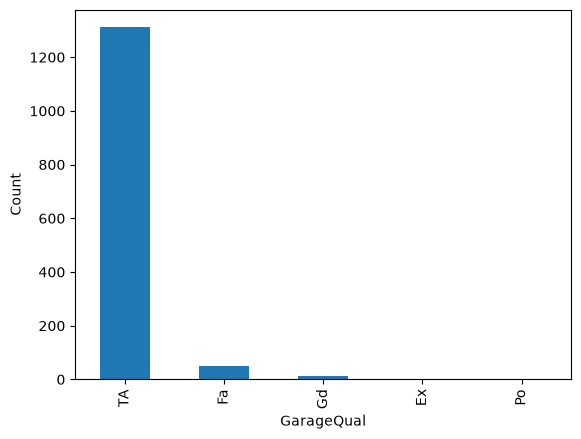

In [107]:
df['GarageQual'].value_counts().plot(kind='bar')
plt.xlabel('GarageQual')
plt.ylabel('Count')

In [108]:
df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: str

Text(0.5, 1.0, 'GarageQual')

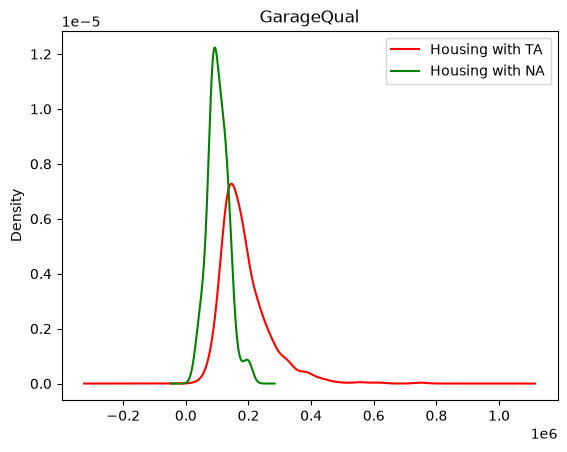

In [109]:
fig = plt.figure()
ax = fig.add_axes(111)

df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde', ax=ax, color='red')
df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='green')

lines, labels = ax.get_legend_handles_labels()
labels = ['Housing with TA','Housing with NA']
ax.legend(lines, labels, loc='best')
plt.title('GarageQual')

In [110]:
temp = df[df['GarageQual'] == 'TA']['SalePrice']

# Using Numpy

In [111]:
df['GarageQual'].fillna('TA', inplace=True)

/var/folders/1f/6m1mrc854l70_ftx18ysbs_r0000gn/T/ipykernel_2146/1818999247.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['GarageQual'].fillna('TA', inplace=True)


0       TA
1       TA
2       TA
3       TA
4       TA
        ..
1455    TA
1456    TA
1457    TA
1458    TA
1459    TA
Name: GarageQual, Length: 1460, dtype: str

<Axes: xlabel='GarageQual'>

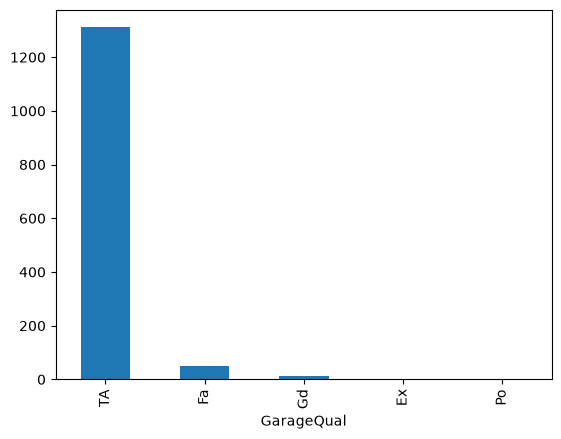

In [112]:
df['GarageQual'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'GarageQual')

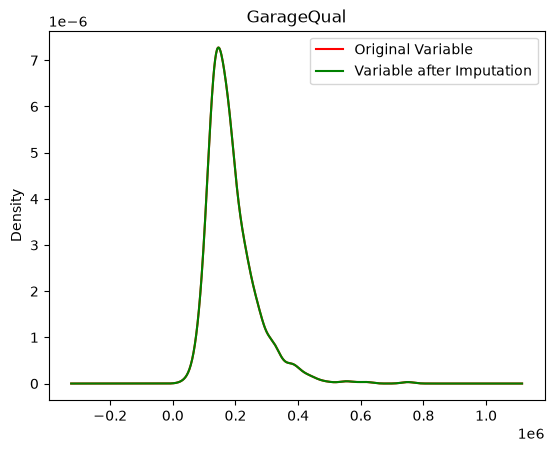

In [113]:
fig = plt.figure()
ax = fig.add_axes(111)

temp.plot(kind='kde', ax=ax, color='red')

# distribution of the variable after imputation
df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde', ax=ax, color='green')

lines, labels = ax.get_legend_handles_labels()
labels = ['Original Variable','Variable after Imputation']
ax.legend(lines, labels, loc='best')

plt.title('GarageQual')

Text(0, 0.5, 'Count')

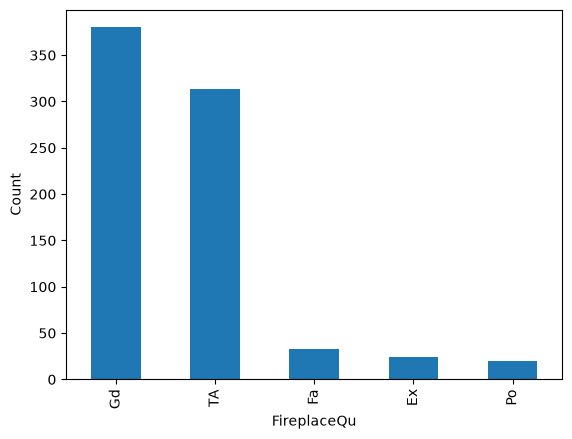

In [114]:
df['FireplaceQu'].value_counts().plot(kind='bar')
plt.xlabel('FireplaceQu')
plt.ylabel('Count')

In [115]:
df['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: str

Text(0.5, 1.0, 'FireplaceQu')

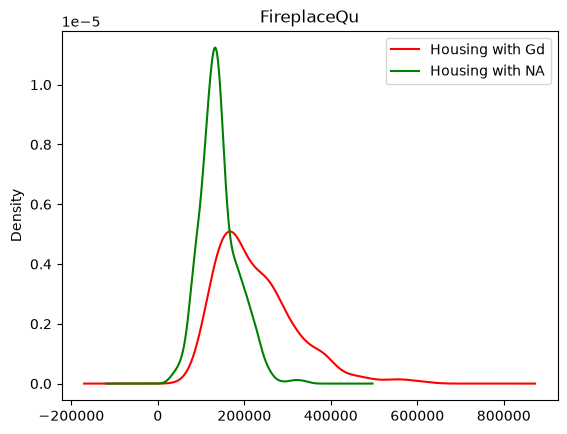

In [116]:
fig = plt.figure()
ax = fig.add_axes(111)

df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde', ax=ax, color='red')
df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='green')

lines, labels = ax.get_legend_handles_labels()
labels = ['Housing with Gd','Housing with NA']
ax.legend(lines, labels, loc='best')
plt.title('FireplaceQu')

In [117]:
temp = df[df['FireplaceQu'] == 'Gd']['SalePrice']

In [118]:
df['FireplaceQu'].fillna('Gd', inplace=True)

/var/folders/1f/6m1mrc854l70_ftx18ysbs_r0000gn/T/ipykernel_2146/3912738894.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['FireplaceQu'].fillna('Gd', inplace=True)


0       Gd
1       TA
2       TA
3       Gd
4       TA
        ..
1455    TA
1456    TA
1457    Gd
1458    Gd
1459    Gd
Name: FireplaceQu, Length: 1460, dtype: str

<Axes: xlabel='FireplaceQu'>

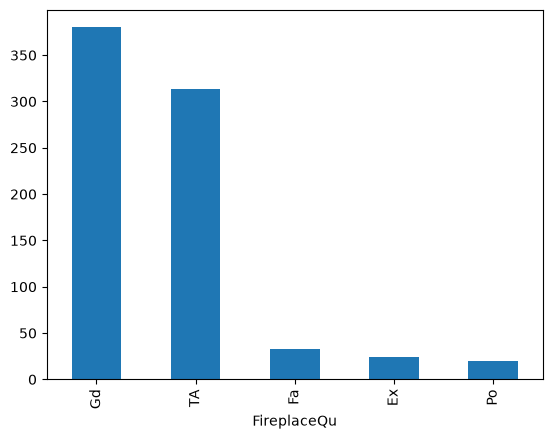

In [119]:
df['FireplaceQu'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'FireplaceQu')

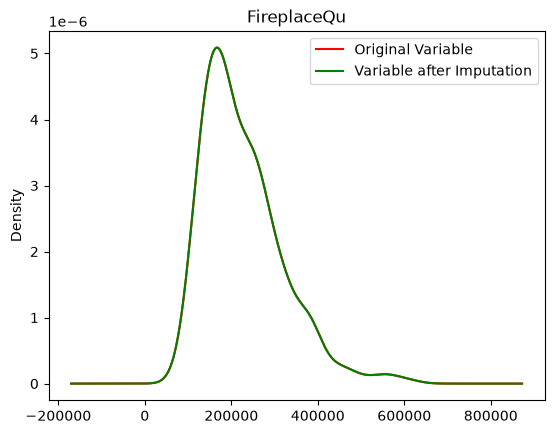

In [120]:
fig = plt.figure()
ax = fig.add_axes(111)

temp.plot(kind='kde', ax=ax, color='red')

# distribution of the variable after imputation
df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde', ax=ax, color='green')

lines, labels = ax.get_legend_handles_labels()
labels = ['Original Variable','Variable after Imputation']
ax.legend(lines, labels, loc='best')

plt.title('FireplaceQu')

# Using Scikit-learn

In [121]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [122]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns='SalePrice'), df['SalePrice'], test_size=0.2, random_state=0)

In [123]:
imputer = SimpleImputer(strategy='most_frequent')

In [124]:
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [125]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)

# For Missing Categorical Data, we can use New Category named as 'Missing' or 'Unknown' to replace the missing values. This is a good approach when the missing values are not random and have some meaning
# Ex-Numpy: df['FireplaceQu'].fillna('Missing', inplace=True)
# Ex-Scikit-learn: imputer = SimpleImputer(strategy='constant', fill_value='Missing')